This is code that explores environmental dependencies, using trait matching functions to create modularity.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
import networkx as nx
from sklearn import metrics
from scipy import stats
from scipy.stats import rankdata

import metaCommunityMx
import community_sim
import metrics_and_plotting
import run_cooccurrence
reload(metaCommunityMx)
reload(community_sim)
reload(metrics_and_plotting)
reload(run_cooccurrence)

import pickle, os
os.makedirs('figure_data', exist_ok=True)

# environment causes modularity
# for random matrix
interactFactor = 1/3
nSpec = 100
pInteract = 0.1
pPositive = 0.5
envStrength = 0.01
cutoff = None 
#cutoff = 0.1

# parms for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpec) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor
b = np.ones(nSpec) - np.random.uniform(low = 0, high = .1, size = (nSpec))

# Trait Matching Environment Noise
traits0 = np.zeros(shape = (nSpec))
traits_unif = np.random.uniform(low = 0, high = 1, size = (nSpec))
traits_bin = np.random.choice([0,1], size = (nSpec))

# null
print("running null")
environ_null = 0
#randMx_0 = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)
nullMx_0 = np.zeros(shape = (nSpec, nSpec))
network_cooc_0, G_coocc_0, pearson_corr_0 = run_cooccurrence.get_coocc_network_traitmatch(interactionMx = nullMx_0, cutoff = cutoff, alpha = alpha, tmax = 300, spsamplesize = samplesize, 
                                                                                        numtrials = numtrials, b = b, traits = traits0, environ = environ_null, envStrength = envStrength)

print("uniform traits and binary environment")
# uniform traits and binary environment
environ = [0,1]
#randMx_0 = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)
network_cooc_unif, G_coocc_unif, pearson_corr_unif = run_cooccurrence.get_coocc_network_traitmatch(interactionMx = nullMx_0, cutoff = cutoff, alpha = alpha, tmax = 800, spsamplesize = samplesize, 
                                                                                        numtrials = numtrials, b = b, traits = traits_unif, environ = environ, envStrength = envStrength)

print("binary traits and binary environment")
# binary traits and binary environment
environ = [0,1]
network_cooc_bin, G_coocc_bin, pearson_corr_bin = run_cooccurrence.get_coocc_network_traitmatch(interactionMx = nullMx_0, cutoff = cutoff, alpha = alpha, tmax = 800, spsamplesize = samplesize, 
                                                                                          numtrials = numtrials, b = b, traits = traits_bin, environ = environ, envStrength = envStrength)


running null
environ was none
uniform traits and binary environment
environ was none
binary traits and binary environment
environ was none


In [3]:
pos_cooc_G_0 = nx.from_numpy_array(np.greater(network_cooc_0, 0).astype(int))
pos_cooc_G_unif = nx.from_numpy_array(np.greater(network_cooc_unif, 0).astype(int))
pos_cooc_G_bin = nx.from_numpy_array(np.greater(network_cooc_bin, 0).astype(int))

mod_clust_coocc_0 = nx.community.greedy_modularity_communities(G_coocc_0)
mod_clust_coocc_unif = nx.community.greedy_modularity_communities(G_coocc_unif)
mod_clust_coocc_bin = nx.community.greedy_modularity_communities(G_coocc_bin)

mod_clust_posCoocc_0 = nx.community.greedy_modularity_communities(pos_cooc_G_0)
mod_clust_posCoocc_unif = nx.community.greedy_modularity_communities(pos_cooc_G_unif)
mod_clust_posCoocc_bin = nx.community.greedy_modularity_communities(pos_cooc_G_bin)

mod_membership_unif = np.argmin(np.abs(np.subtract.outer(traits_unif, environ)), axis=1)
mod_membership_sets_unif = [set(np.where(mod_membership_unif == i)[0]) for i in range(len(environ))]

mod_membership_bin = np.argmin(np.abs(np.subtract.outer(traits_bin, environ)), axis=1)
mod_membership_sets_bin = [set(np.where(mod_membership_bin == i)[0]) for i in range(len(environ))]

# compare environment clusters and co-occurrence clusters
mod_shared_pairs_env0, mod_both_non_pairs_env0, mod_c1_not_c2_env0, mod_c2_not_c1_env0, mod_prop_correct_env0 = \
            metrics_and_plotting.test_cluster_similarity(mod_clust_coocc_0, mod_membership_sets_unif)

mod_shared_pairs_env, mod_both_non_pairs_env_unif, mod_c1_not_c2_env_unif, mod_c2_not_c1_env_unif, mod_prop_correct_env_unif = \
            metrics_and_plotting.test_cluster_similarity(mod_clust_coocc_unif, mod_membership_sets_unif)
mod_shared_pairs_env_bin, mod_both_non_pairs_env_bin, mod_c1_not_c2_env_bin, mod_c2_not_c1_env_bin, mod_prop_correct_env_bin = \
            metrics_and_plotting.test_cluster_similarity(mod_clust_coocc_bin, mod_membership_sets_bin)

print("for negative and positive cooc")
print("null")
print(mod_prop_correct_env0)
print("env with uniform traits")
print(mod_prop_correct_env_unif)
print("env with binary traits")
print(mod_prop_correct_env_bin)

# compare environment clusters and co-occurrence clusters for positive co-occurrence
mod_shared_pairs_envPos0, mod_both_non_pairs_envPos0, mod_c1_not_c2_envPos0, mod_c2_not_c1_envPos0, mod_prop_correct_envPos0 = \
            metrics_and_plotting.test_cluster_similarity(mod_clust_posCoocc_0, mod_membership_sets_unif)

# compare environment clusters and co-occurrence clusters for positive co-occurrence
mod_shared_pairs_envPos_unif, mod_both_non_pairs_envPos_unif, mod_c1_not_c2_envPos_unif, mod_c2_not_c1_envPos_unif, mod_prop_correct_envPos_unif = \
            metrics_and_plotting.test_cluster_similarity(mod_clust_posCoocc_unif, mod_membership_sets_unif)

# compare environment clusters and co-occurrence clusters for positive co-occurrence
mod_shared_pairs_envPos_bin, mod_both_non_pairs_envPos_bin, mod_c1_not_c2_envPos_bin, mod_c2_not_c1_envPos_bin, mod_prop_correct_envPos_bin = \
            metrics_and_plotting.test_cluster_similarity(mod_clust_posCoocc_bin, mod_membership_sets_bin)

print("for negative and positive cooc")
print("null")
print(mod_prop_correct_envPos0)
print("env with uniform traits")
print(mod_prop_correct_envPos_unif)
print("env with binary traits")
print(mod_prop_correct_envPos_bin)

for negative and positive cooc
null
0.48343434343434344
env with uniform traits
0.4808080808080808
env with binary traits
0.5038383838383839
for negative and positive cooc
null
0.4822222222222222
env with uniform traits
0.48303030303030303
env with binary traits
0.5070707070707071


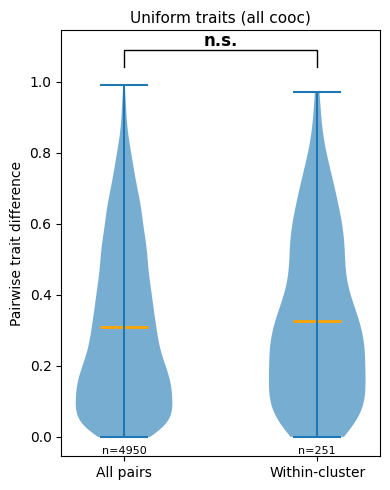

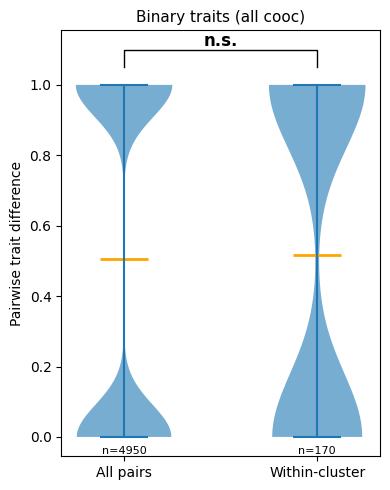

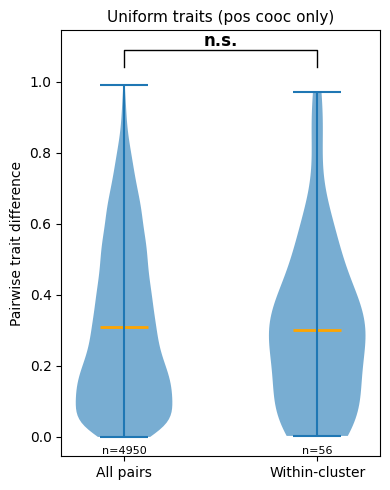

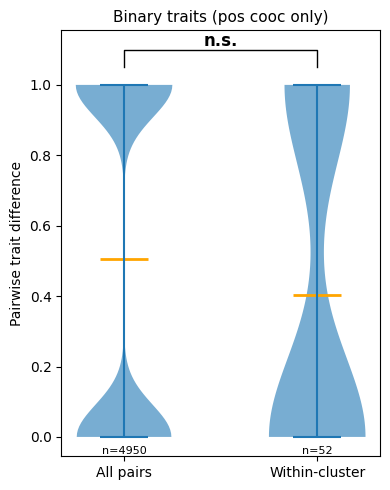

In [5]:
# Figure data saved in figure_data/re_cluster_traits.pkl

# Violin plots: within-cluster trait differences
scenarios_violin = [
    ("Uniform traits (all cooc)", traits_unif, mod_clust_coocc_unif),
    ("Binary traits (all cooc)", traits_bin, mod_clust_coocc_bin),
    ("Uniform traits (pos cooc only)", traits_unif, mod_clust_posCoocc_unif),
    ("Binary traits (pos cooc only)", traits_bin, mod_clust_posCoocc_bin),
]

for title, traits, clusters in scenarios_violin:
    fig, ax = plt.subplots(figsize=(4, 5))
    
    all_diffs = get_pairwise_trait_diffs(traits)
    within_diffs = get_within_cluster_diffs(traits, clusters)
    
    parts = ax.violinplot([all_diffs, within_diffs], positions=[1, 2], showmeans=True, showmedians=False)
    for pc in parts['bodies']:
        pc.set_alpha(0.6)
    parts['cmeans'].set_color('orange')
    parts['cmeans'].set_linewidth(2)
    
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['All pairs', 'Within-cluster'])
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Pairwise trait difference')
    
    # t-test for difference in means
    t_stat, p_val = stats.ttest_ind(all_diffs, within_diffs)
    stars = significance_stars(p_val)
    
    # draw significance bracket
    y_max = max(max(all_diffs), max(within_diffs))
    y_bar = y_max * 1.05
    y_text = y_max * 1.1
    ax.plot([1, 1, 2, 2], [y_bar, y_text, y_text, y_bar], 'k-', linewidth=1)
    ax.text(1.5, y_text, stars, ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # add sample sizes
    ax.text(1, ax.get_ylim()[0], f'n={len(all_diffs)}', ha='center', va='bottom', fontsize=8)
    ax.text(2, ax.get_ylim()[0], f'n={len(within_diffs)}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()

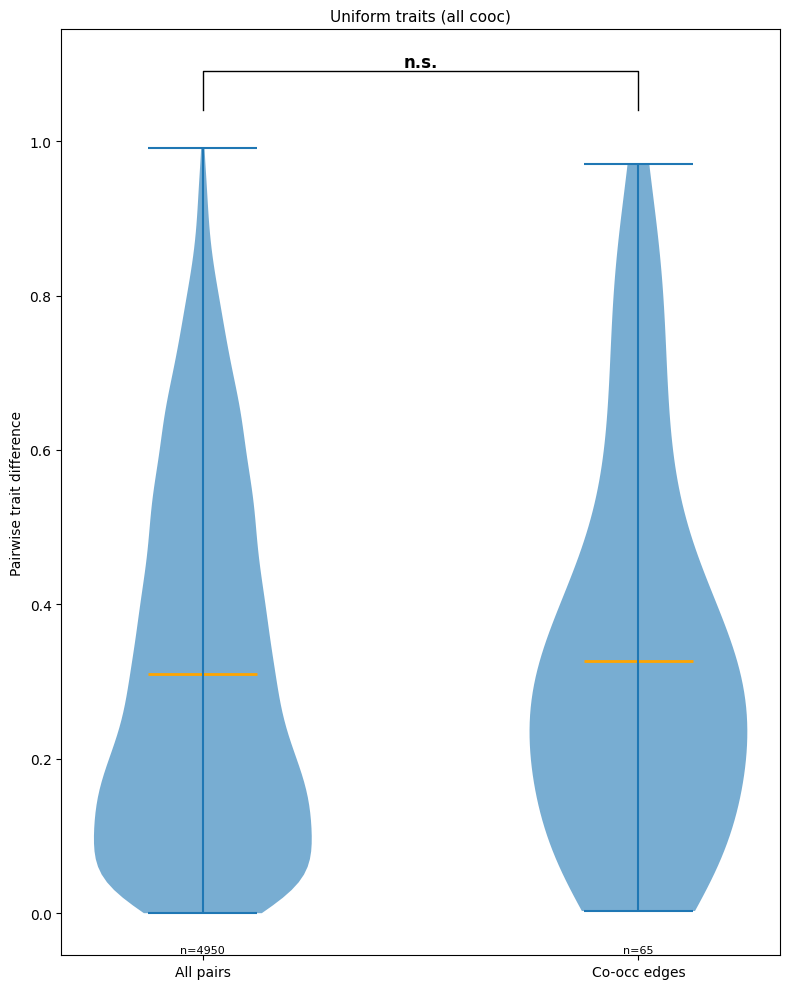

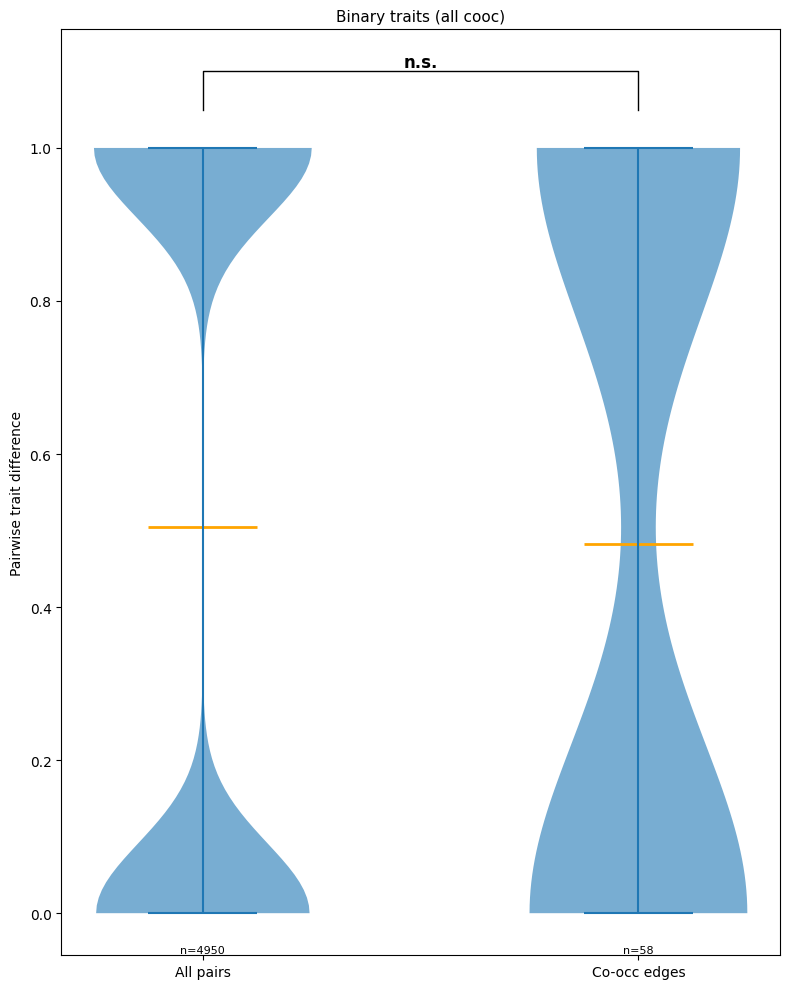

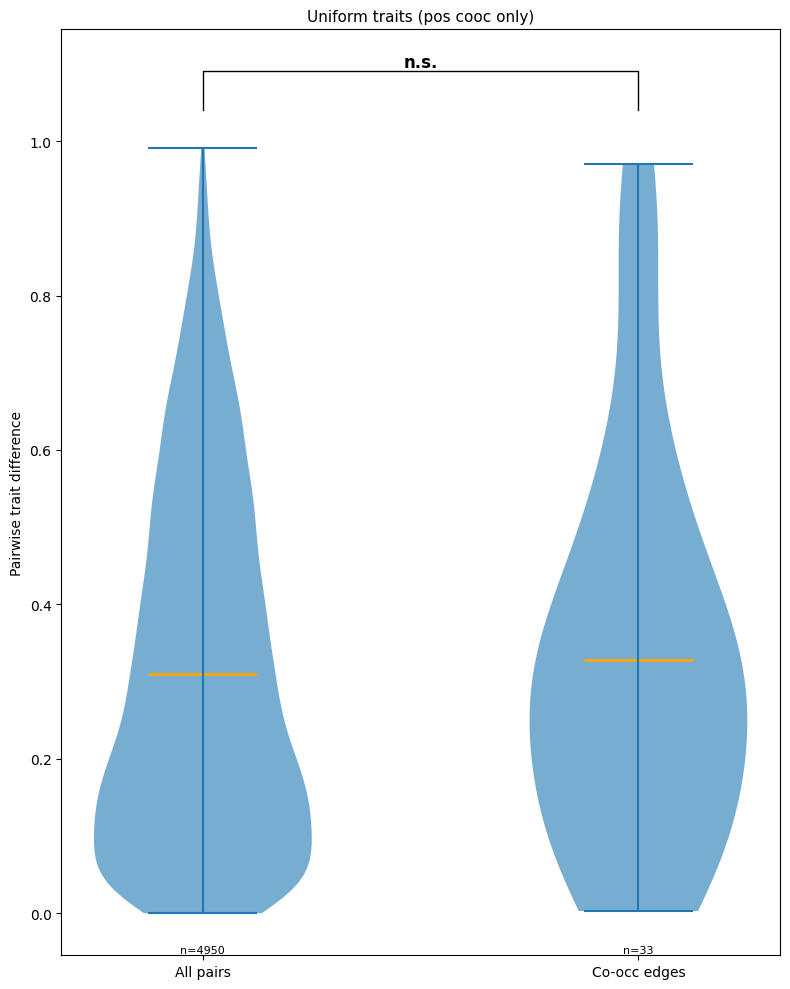

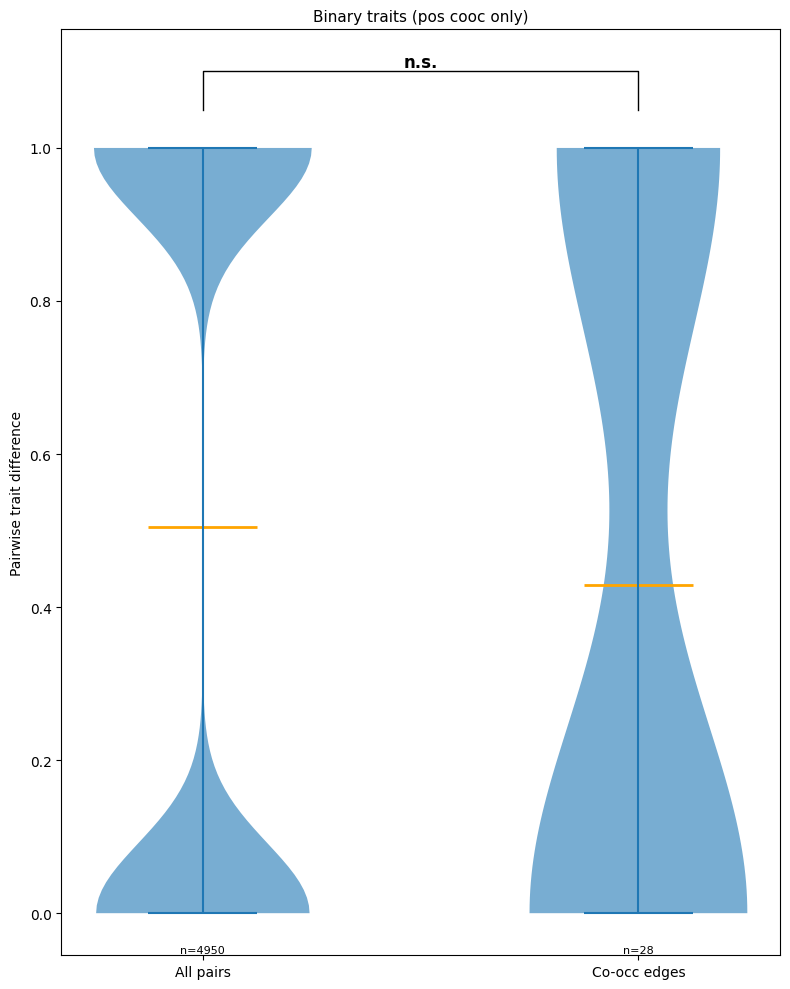

In [7]:
# Figure data saved in figure_data/re_edge_traits.pkl

# Violin plots: co-occurrence edge trait differences
scenarios_violin2 = [
    ("Uniform traits (all cooc)", traits_unif, network_cooc_unif),
    ("Binary traits (all cooc)", traits_bin, network_cooc_bin),
    ("Uniform traits (pos cooc only)", traits_unif, np.greater(network_cooc_unif, 0).astype(int)),
    ("Binary traits (pos cooc only)", traits_bin, np.greater(network_cooc_bin, 0).astype(int)),
]

for title, traits, network in scenarios_violin2:
    fig, ax = plt.subplots(figsize=(8, 10))
    
    all_diffs = get_pairwise_trait_diffs(traits)
    edge_diffs = get_edge_trait_diffs(traits, network)
    
    parts = ax.violinplot([all_diffs, edge_diffs], positions=[1, 2], showmeans=True, showmedians=False)
    for pc in parts['bodies']:
        pc.set_alpha(0.6)
    parts['cmeans'].set_color('orange')
    parts['cmeans'].set_linewidth(2)
    
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['All pairs', 'Co-occ edges'])
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Pairwise trait difference')
    
    # t-test for difference in means
    t_stat, p_val = stats.ttest_ind(all_diffs, edge_diffs)
    stars = significance_stars(p_val)
    
    # draw significance bracket
    y_max = max(max(all_diffs), max(edge_diffs))
    y_bar = y_max * 1.05
    y_text = y_max * 1.1
    ax.plot([1, 1, 2, 2], [y_bar, y_text, y_text, y_bar], 'k-', linewidth=1)
    ax.text(1.5, y_text, stars, ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # add sample sizes
    ax.text(1, ax.get_ylim()[0], f'n={len(all_diffs)}', ha='center', va='bottom', fontsize=8)
    ax.text(2, ax.get_ylim()[0], f'n={len(edge_diffs)}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()

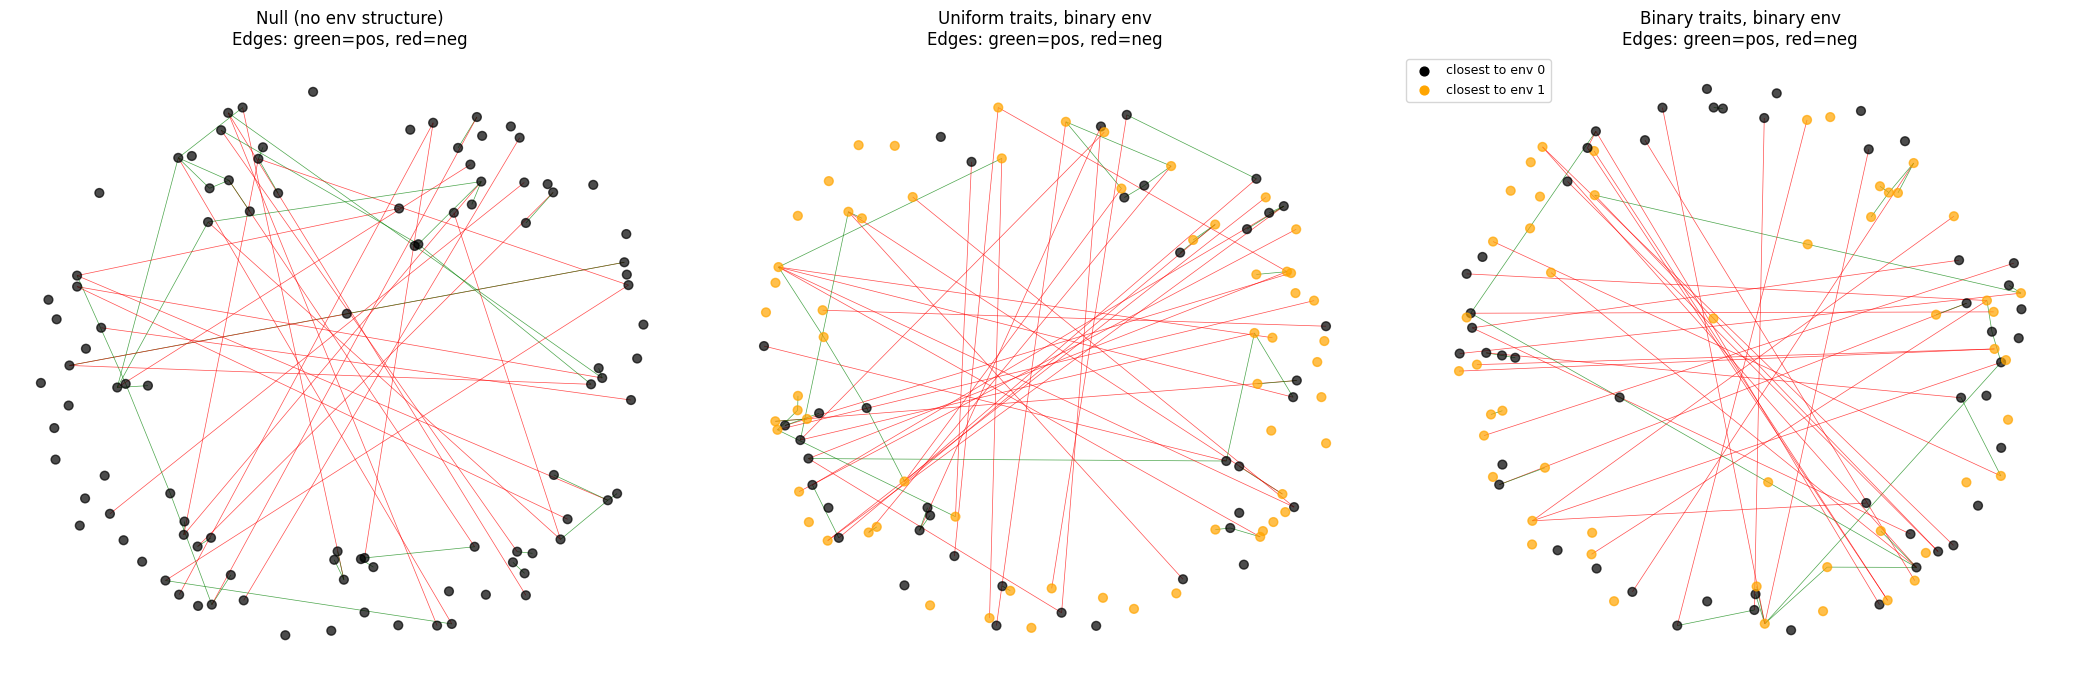

In [ ]:
# Plot co-occurrence networks, nodes colored by trait group membership
with open('figure_data/re_network_viz.pkl', 'wb') as f:
    pickle.dump({
        'adj_coocc_0': nx.to_numpy_array(G_coocc_0),
        'adj_coocc_unif': nx.to_numpy_array(G_coocc_unif),
        'adj_coocc_bin': nx.to_numpy_array(G_coocc_bin),
        'network_cooc_0': network_cooc_0,
        'network_cooc_unif': network_cooc_unif,
        'network_cooc_bin': network_cooc_bin,
        'mod_membership_unif': mod_membership_unif,
        'mod_membership_bin': mod_membership_bin,
        'nSpec': nSpec,
        'environ': environ,
    }, f)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 7))

cmap_colors = ['black', 'orange']

# Null: no env structure, all traits = 0 so all closest to env 0
node_colors_0 = [cmap_colors[0] for _ in range(nSpec)]
pos0 = nx.spring_layout(G_coocc_0, seed=42)
edge_colors_0 = ['green' if network_cooc_0[u,v] > 0 else 'red' for u,v in G_coocc_0.edges()]
nx.draw(G_coocc_0, pos0, ax=ax1, with_labels=False, node_color=node_colors_0,
        node_size=40, edge_color=edge_colors_0, width=0.5, alpha=0.7)
ax1.set_title("Null (no env structure)\nEdges: green=pos, red=neg")

# Uniform traits, binary environment
node_colors_unif = [cmap_colors[mod_membership_unif[i]] for i in range(nSpec)]
pos_unif = nx.spring_layout(G_coocc_unif, seed=42)
edge_colors_unif = ['green' if network_cooc_unif[u,v] > 0 else 'red' for u,v in G_coocc_unif.edges()]
nx.draw(G_coocc_unif, pos_unif, ax=ax2, with_labels=False, node_color=node_colors_unif,
        node_size=40, edge_color=edge_colors_unif, width=0.5, alpha=0.7)
ax2.set_title("Uniform traits, binary env\nEdges: green=pos, red=neg")

# Binary traits, binary environment
node_colors_bin = [cmap_colors[mod_membership_bin[i]] for i in range(nSpec)]
pos_bin = nx.spring_layout(G_coocc_bin, seed=42)
edge_colors_bin = ['green' if network_cooc_bin[u,v] > 0 else 'red' for u,v in G_coocc_bin.edges()]
nx.draw(G_coocc_bin, pos_bin, ax=ax3, with_labels=False, node_color=node_colors_bin,
        node_size=40, edge_color=edge_colors_bin, width=0.5, alpha=0.7)
ax3.set_title("Binary traits, binary env\nEdges: green=pos, red=neg")

# Legend for trait groups
for k, env_val in enumerate(environ):
    ax3.scatter([], [], c=[cmap_colors[k]], label=f'closest to env {env_val}', s=40)
ax3.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

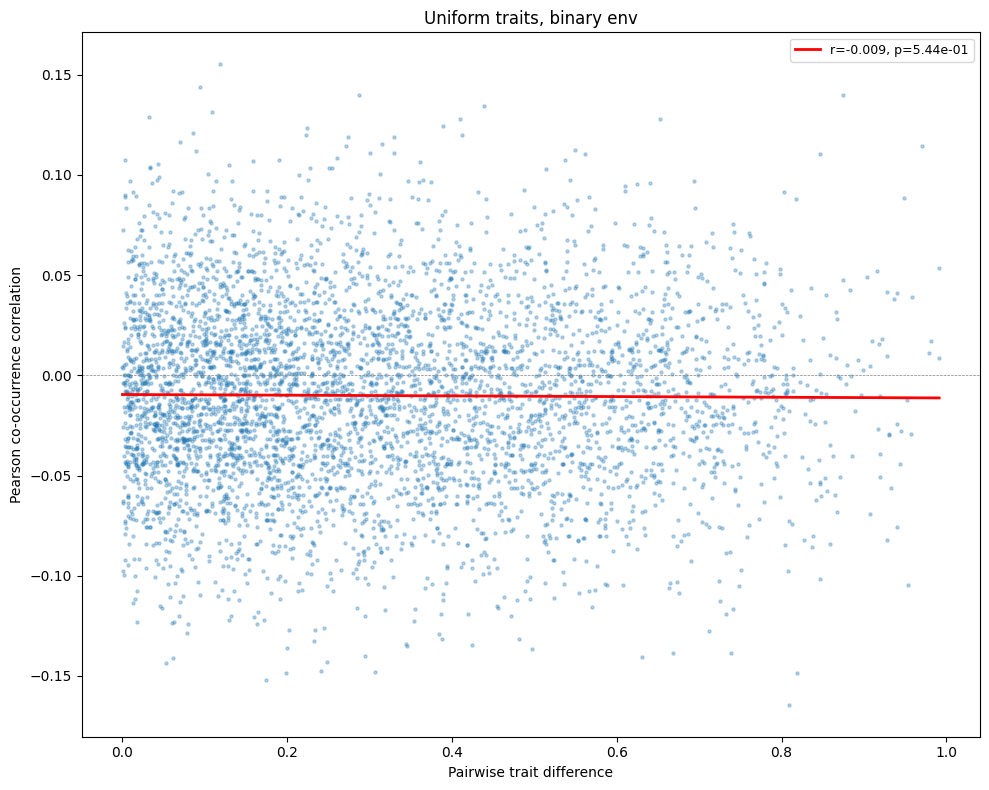

In [ ]:
# plot pairwise co-occurrence pearson correlation versus pairwise difference in trait values for uniform traits, binary env

n = len(traits_unif)
iu = np.triu_indices(n, k=1)
trait_diffs = np.abs(traits_unif[iu[0]] - traits_unif[iu[1]])
pears_vals = pearson_corr_unif[iu[0], iu[1]]

with open('figure_data/re_trait_scatter.pkl', 'wb') as f:
    pickle.dump({
        'traits_unif': traits_unif,
        'pearson_corr_unif': pearson_corr_unif,
    }, f)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(trait_diffs, pears_vals, s=5, alpha=0.3)
ax.set_xlabel('Pairwise trait difference')
ax.set_ylabel('Pearson co-occurrence correlation')
ax.set_title('Uniform traits, binary env')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)

slope, intercept, r, p, se = stats.linregress(trait_diffs, pears_vals)
x_line = np.linspace(trait_diffs.min(), trait_diffs.max(), 100)
ax.plot(x_line, intercept + slope * x_line, 'r', linewidth=2,
        label=f'r={r:.3f}, p={p:.2e}')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

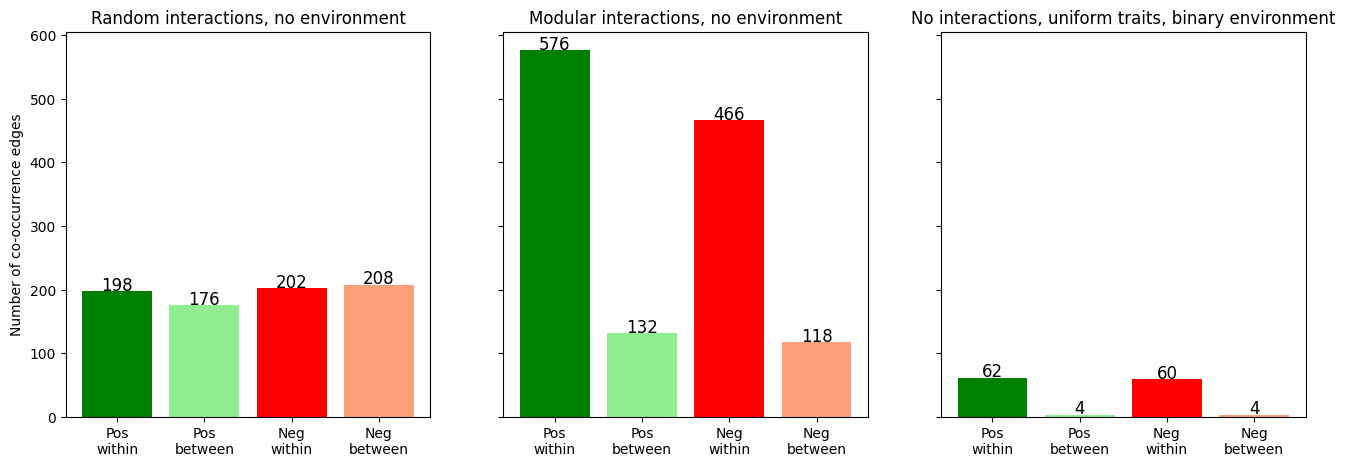

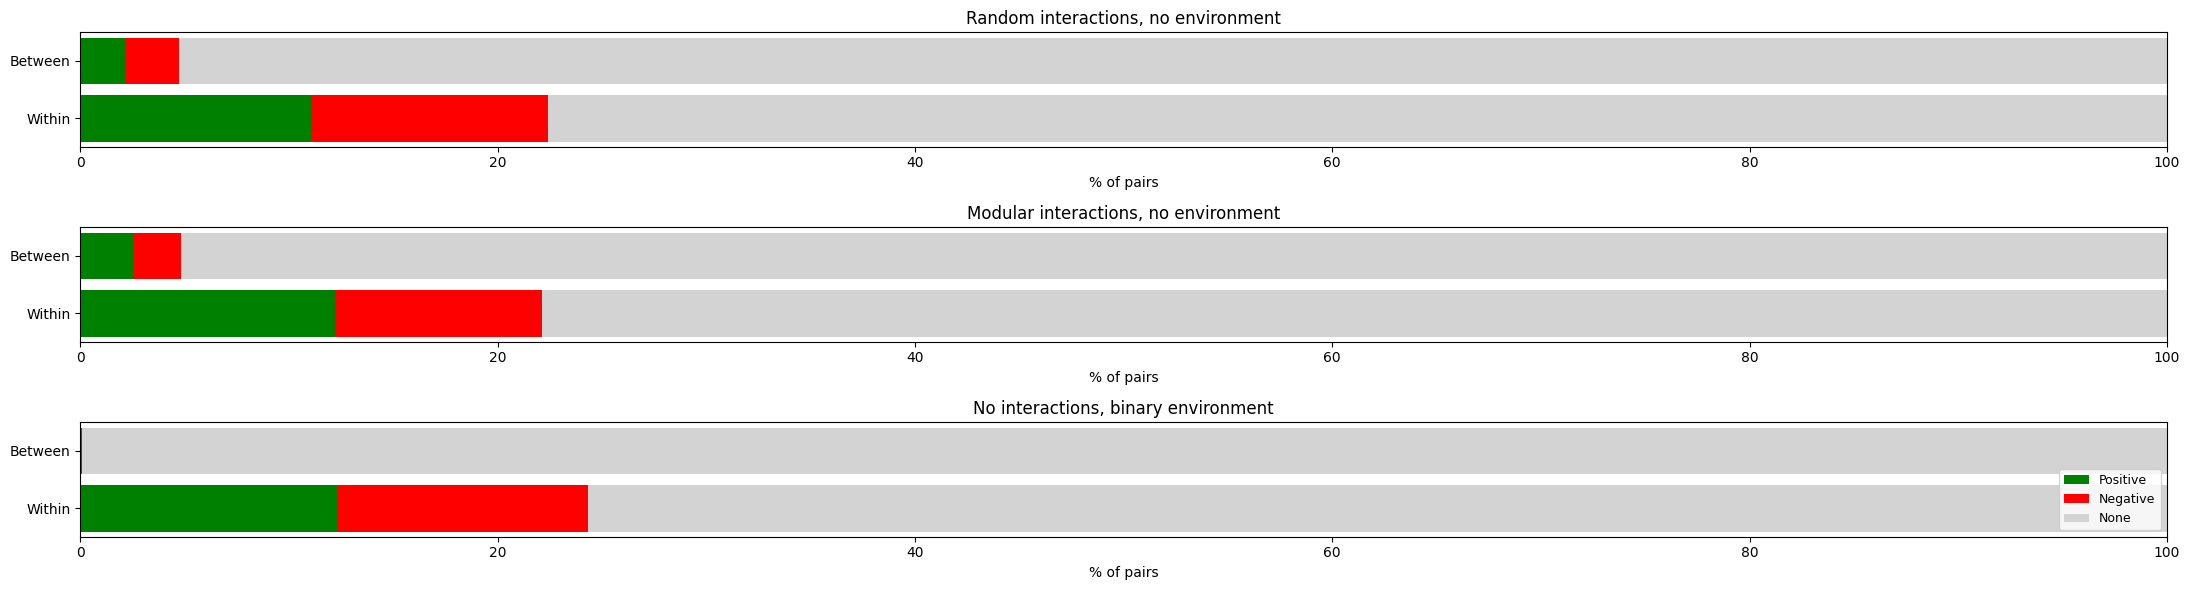

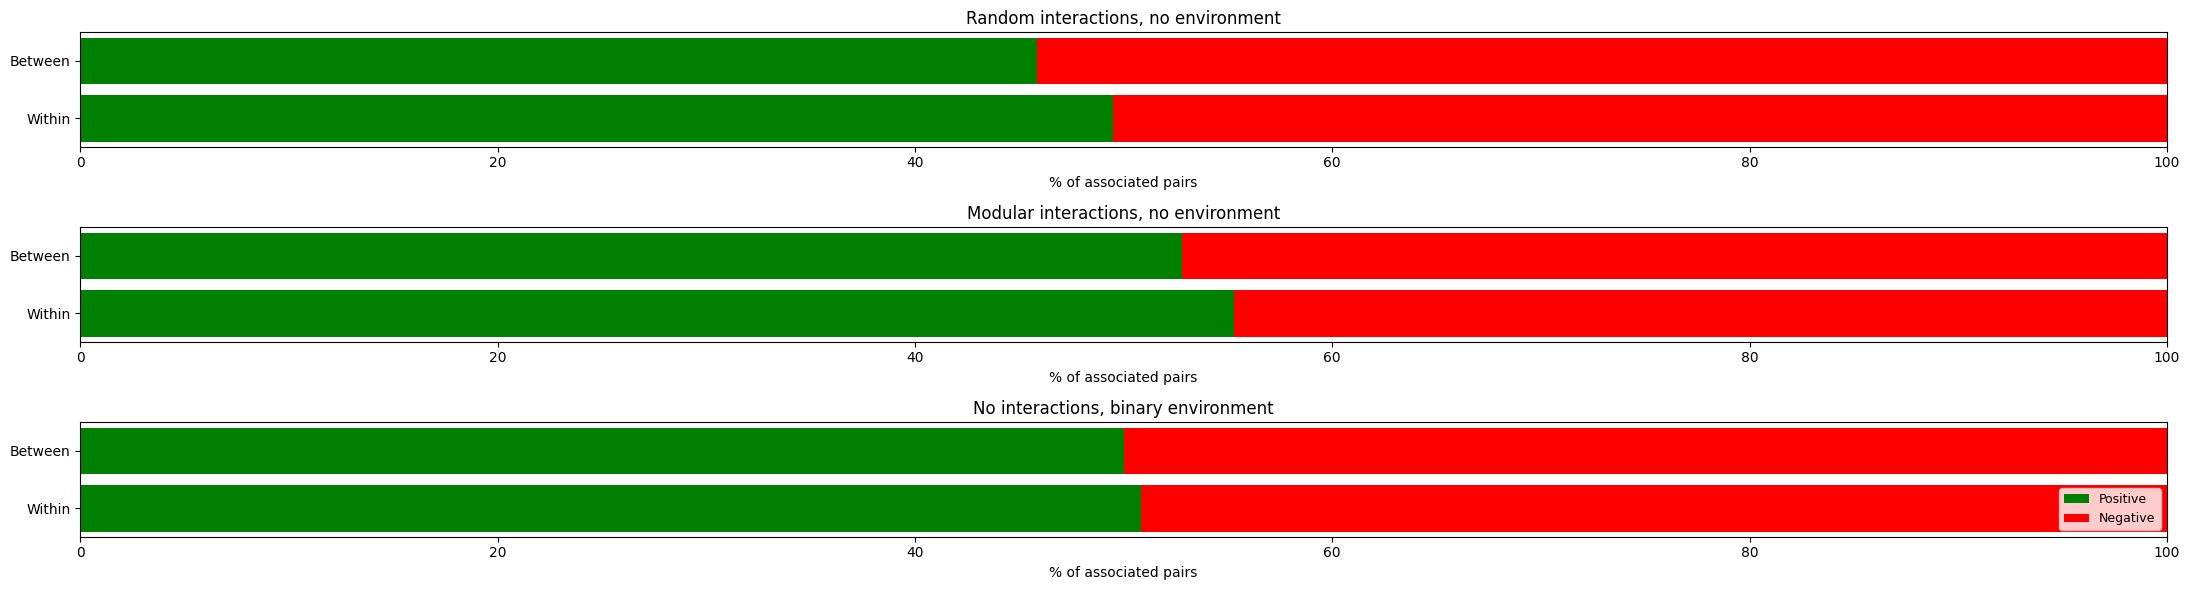

In [ ]:
# make an interaction network (random interactions)
# then make modules from the co-occurrence network
# then count the positive interactions within modules and the positive interactions between modules
# then count the negative interactions within modules and the negative interactions between modules

# make an environment network (no interactions, uniform traits, binary environment)
# then make modules from the co-occurrence network
# then count the positive interactions within modules and the positive interactions between modules
# then count the negative interactions within modules and the negative interactions between modules

# make bar plots of this

def count_edge_sign_within_between(network, clusters):
    """Count positive and negative co-occurrence edges within and between modules.
    
    network: numpy array (+1 = positive edge, -1 = negative edge)
    clusters: list of sets from community detection
    
    Returns: (pos_within, neg_within, pos_between, neg_between)

    Note: this will double count co-occurrence edges because it will count in both directions. But proportions should be fine.
    """
    n = network.shape[0]
    membership = np.zeros(n, dtype=int)
    for idx, cluster in enumerate(clusters):
        for node in cluster:
            membership[node] = idx
    
    pos_within = 0
    neg_within = 0
    pos_between = 0
    neg_between = 0
    
    for i in range(n):
        for j in range(n):
            if i != j:
                if network[i, j] > 0:
                    if membership[i] == membership[j]:
                        pos_within += 1
                    else:
                        pos_between += 1
                elif network[i, j] < 0:
                    if membership[i] == membership[j]:
                        neg_within += 1
                    else:
                        neg_between += 1
    
    return pos_within, neg_within, pos_between, neg_between

# Interaction network (random interactions, no environment)
randMx_interact = metaCommunityMx.getRandomMatrix(maxInteractionStrength=interactStren, pPositive=pPositive, 
                                                pInteract=pInteract, nSpecies=nSpec, pBidirectional=0)
network_cooc_wInteractions, G_coocc_wInteractions = run_cooccurrence.get_coocc_network(interactionMx=randMx_interact, cutoff=cutoff, 
                                                                alpha=alpha, tmax=300, spsamplesize=samplesize, numtrials=numtrials, b=b)

# Interaction network (modular interactions, no environment)
modMx_interact = metaCommunityMx.generateModularMatrix(maxInteractionStrength=interactStren, pPositive=pPositive, pWithinMod = 0.3, pBetweenMod = 0.05, nModules = 2, nSpecies = nSpec)
network_cooc_wModInteractions, G_coocc_wModInteractions = run_cooccurrence.get_coocc_network(interactionMx=modMx_interact, cutoff=cutoff, 
                                                                alpha=alpha, tmax=300, spsamplesize=samplesize, numtrials=numtrials, b=b)

# Detect modules from co-occ and count signs of edges
mod_clust_wInteractions = nx.community.greedy_modularity_communities(G_coocc_wInteractions)
pos_w_int, neg_w_int, pos_b_int, neg_b_int = count_edge_sign_within_between(network_cooc_wInteractions, mod_clust_wInteractions)

mod_clust_wModInteractions = nx.community.greedy_modularity_communities(G_coocc_wModInteractions)
pos_w_mod, neg_w_mod, pos_b_mod, neg_b_mod = count_edge_sign_within_between(network_cooc_wModInteractions, mod_clust_wModInteractions)

# Environment network (no interactions, uniform traits, binary env)
# Already computed above: network_cooc_unif, G_coocc_unif
# Detect modules from co-occ and count signs of edges
mod_clust_env = nx.community.greedy_modularity_communities(G_coocc_unif)
pos_w_env, neg_w_env, pos_b_env, neg_b_env = count_edge_sign_within_between(network_cooc_unif, mod_clust_env)

with open('figure_data/re_edge_signs_all.pkl', 'wb') as f:
    pickle.dump({
        'network_cooc_wInteractions': network_cooc_wInteractions,
        'network_cooc_wModInteractions': network_cooc_wModInteractions,
        'network_cooc_unif': network_cooc_unif,
        'counts_int': [pos_w_int, pos_b_int, neg_w_int, neg_b_int],
        'counts_mod': [pos_w_mod, pos_b_mod, neg_w_mod, neg_b_mod],
        'counts_env': [pos_w_env, pos_b_env, neg_w_env, neg_b_env],
        'mod_clust_wInteractions': [list(c) for c in mod_clust_wInteractions],
        'mod_clust_wModInteractions': [list(c) for c in mod_clust_wModInteractions],
        'mod_clust_env': [list(c) for c in mod_clust_env],
        'nSpec': nSpec,
        'pos_w_int': pos_w_int, 'neg_w_int': neg_w_int, 'pos_b_int': pos_b_int, 'neg_b_int': neg_b_int,
        'pos_w_mod': pos_w_mod, 'neg_w_mod': neg_w_mod, 'pos_b_mod': pos_b_mod, 'neg_b_mod': neg_b_mod,
        'pos_w_env': pos_w_env, 'neg_w_env': neg_w_env, 'pos_b_env': pos_b_env, 'neg_b_env': neg_b_env,
    }, f)

# PLOT
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

categories = ['Pos\nwithin', 'Pos\nbetween', 'Neg\nwithin', 'Neg\nbetween']
colors = ['green', 'lightgreen', 'red', 'lightsalmon']

# network with random interactions
counts_int = [pos_w_int, pos_b_int, neg_w_int, neg_b_int]
ax1.bar(categories, counts_int, color=colors)
ax1.set_title('Random interactions, no environment')
ax1.set_ylabel('Number of co-occurrence edges')
for i, v in enumerate(counts_int):
    ax1.text(i, v + 1, str(v), ha='center', fontsize=12)

# network with modular interactions
counts_mod = [pos_w_mod, pos_b_mod, neg_w_mod, neg_b_mod]
ax2.bar(categories, counts_mod, color=colors)
ax2.set_title('Modular interactions, no environment')
for i, v in enumerate(counts_mod):
    ax2.text(i, v + 1, str(v), ha='center', fontsize=12)

# Environment network
counts_env = [pos_w_env, pos_b_env, neg_w_env, neg_b_env]
ax3.bar(categories, counts_env, color=colors)
ax3.set_title('No interactions, uniform traits, binary environment')
for i, v in enumerate(counts_env):
    ax3.text(i, v + 1, str(v), ha='center', fontsize=12)

plt.show()

# Stacked 100% bar charts: proportion of pos / neg / no-edge pairs within and between modules

def plot_stacked_100(ax, pos_w, neg_w, pos_b, neg_b, clusters, n, title, show_legend=False):
    sizes = [len(c) for c in clusters]
    total_within = sum(s * (s - 1) for s in sizes)   # directed pairs, matches double-counting in count_edge_sign_within_between
    total_between = n * (n - 1) - total_within

    none_w = total_within - pos_w - neg_w
    none_b = total_between - pos_b - neg_b

    pw = pos_w / total_within * 100
    nw = neg_w / total_within * 100
    xw = none_w / total_within * 100

    pb = pos_b / total_between * 100
    nb = neg_b / total_between * 100
    xb = none_b / total_between * 100

    bars = ['Within', 'Between']
    ax.barh(bars, [pw, pb], color='green', label='Positive')
    ax.barh(bars, [nw, nb], left=[pw, pb], color='red', label='Negative')
    ax.barh(bars, [xw, xb], left=[pw + nw, pb + nb], color='lightgray', label='None')

    ax.set_xlim(0, 100)
    ax.set_xlabel('% of pairs')
    ax.set_title(title)
    if show_legend:
        ax.legend(loc='lower right', fontsize=9)

def plot_stacked_posNeg(ax, pos_w, neg_w, pos_b, neg_b, title, show_legend=False):
    pw = pos_w / (pos_w + neg_w) * 100
    nw = neg_w / (pos_w + neg_w) * 100

    pb = pos_b / (pos_b + neg_b) * 100
    nb = neg_b / (pos_b + neg_b) * 100

    bars = ['Within', 'Between']
    ax.barh(bars, [pw, pb], color='green', label='Positive')
    ax.barh(bars, [nw, nb], left=[pw, pb], color='red', label='Negative')

    ax.set_xlim(0, 100)
    ax.set_xlabel('% of associated pairs')
    ax.set_title(title)
    if show_legend:
        ax.legend(loc='lower right', fontsize=9)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(22, 6), sharey=True)

plot_stacked_100(ax1, pos_w_int, neg_w_int, pos_b_int, neg_b_int, mod_clust_wInteractions, nSpec,
                 'Random interactions, no environment')
plot_stacked_100(ax2, pos_w_mod, neg_w_mod, pos_b_mod, neg_b_mod, mod_clust_wModInteractions, nSpec,
                 'Modular interactions, no environment')
plot_stacked_100(ax3, pos_w_env, neg_w_env, pos_b_env, neg_b_env, mod_clust_env, nSpec,
                 'No interactions, binary environment', show_legend=True)

plt.tight_layout()
plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(22, 6), sharey=True)

plot_stacked_posNeg(ax1, pos_w_int, neg_w_int, pos_b_int, neg_b_int,
                 'Random interactions, no environment')
plot_stacked_posNeg(ax2, pos_w_mod, neg_w_mod, pos_b_mod, neg_b_mod,
                 'Modular interactions, no environment')
plot_stacked_posNeg(ax3, pos_w_env, neg_w_env, pos_b_env, neg_b_env,
                 'No interactions, binary environment', show_legend=True)

plt.tight_layout()
plt.show()

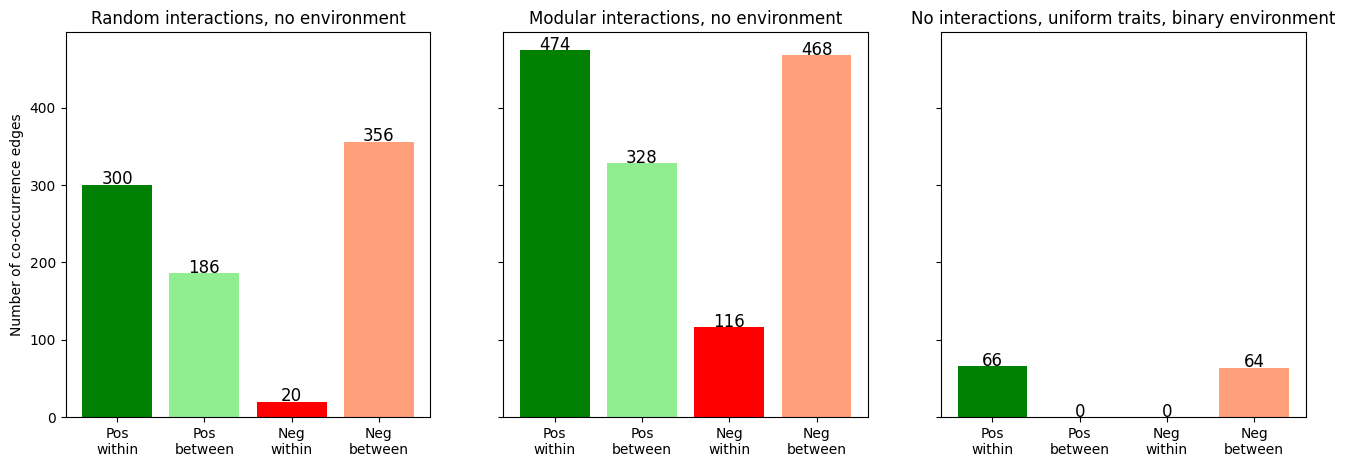

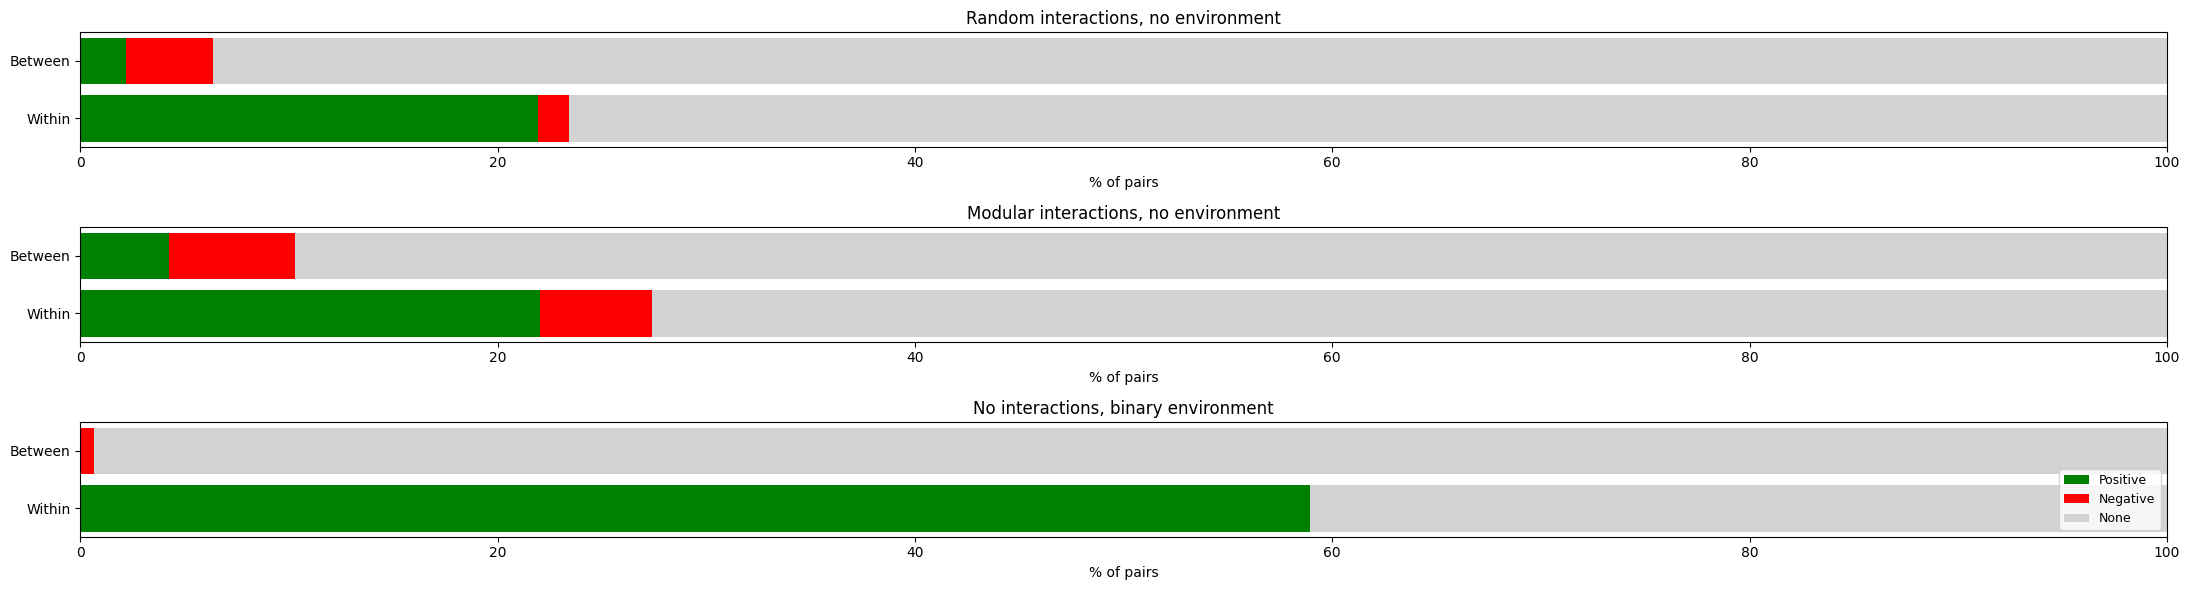

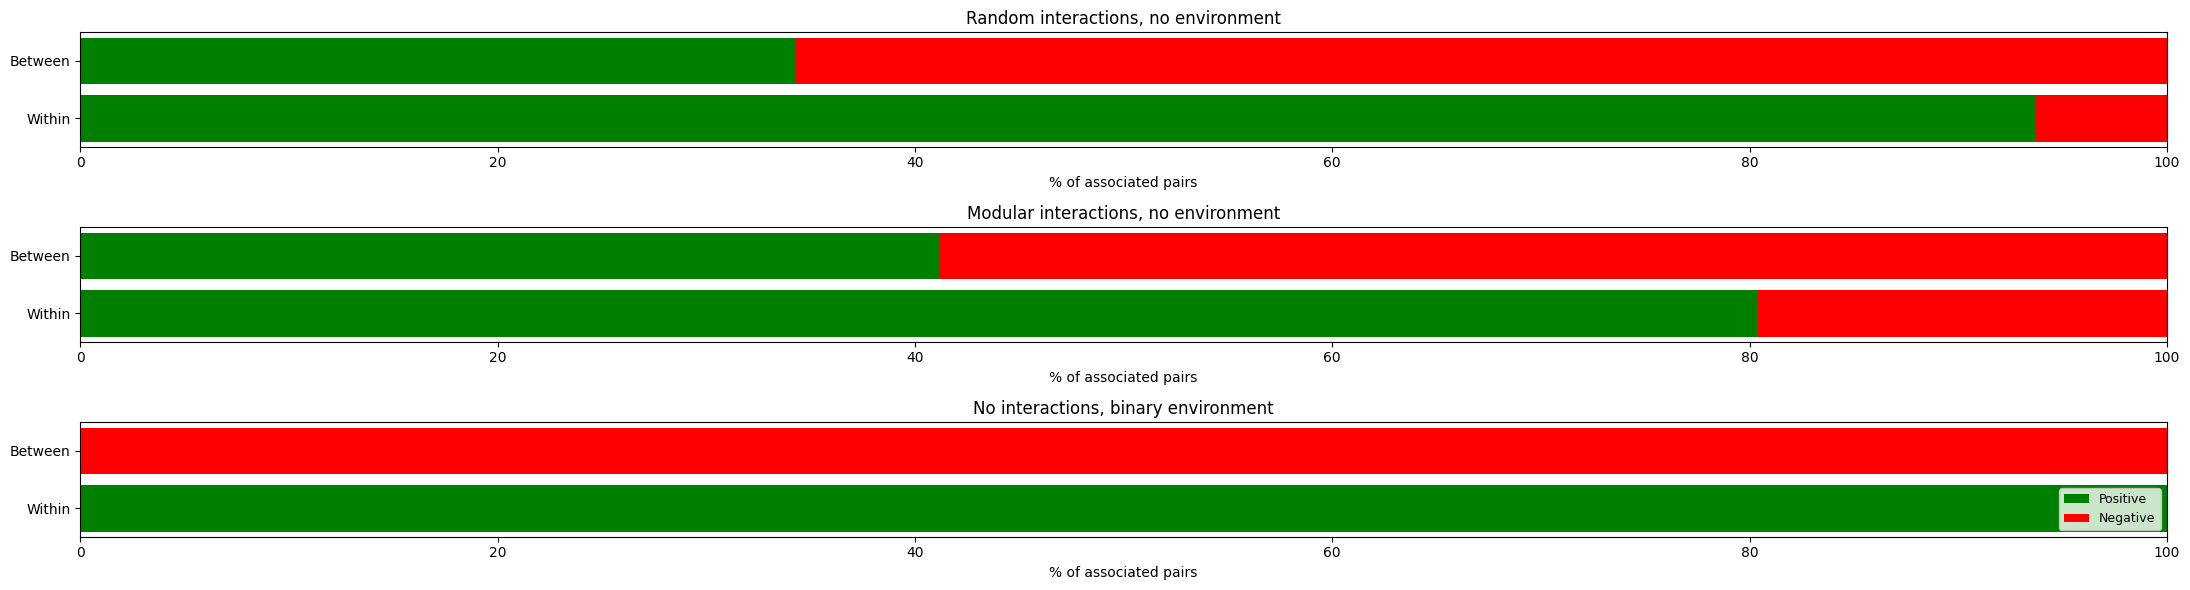

In [ ]:
## same as above except build modules with only pos interactions

# make an interaction network (random interactions)
# then make modules from the co-occurrence network
# then count the positive interactions within modules and the positive interactions between modules
# then count the negative interactions within modules and the negative interactions between modules

# make an environment network (no interactions, uniform traits, binary environment)
# then make modules from the co-occurrence network
# then count the positive interactions within modules and the positive interactions between modules
# then count the negative interactions within modules and the negative interactions between modules

# make bar plots of this

# Interaction network (random interactions, no environment)
randMx_interact = metaCommunityMx.getRandomMatrix(maxInteractionStrength=interactStren, pPositive=pPositive, 
                                                pInteract=pInteract, nSpecies=nSpec, pBidirectional=0)
network_cooc_wInteractions, G_coocc_wInteractions = run_cooccurrence.get_coocc_network(interactionMx=randMx_interact, cutoff=cutoff, 
                                                                alpha=alpha, tmax=300, spsamplesize=samplesize, numtrials=numtrials, b=b)

# Interaction network (modular interactions, no environment)
modMx_interact = metaCommunityMx.generateModularMatrix(maxInteractionStrength=interactStren, pPositive=pPositive, pWithinMod = 0.3, pBetweenMod = 0.05, nModules = 2, nSpecies = nSpec)
network_cooc_wModInteractions, G_coocc_wModInteractions = run_cooccurrence.get_coocc_network(interactionMx=modMx_interact, cutoff=cutoff, 
                                                                alpha=alpha, tmax=300, spsamplesize=samplesize, numtrials=numtrials, b=b)

# Detect modules from co-occ and count signs of edges
G_coocc_wInteractions_pos = nx.from_numpy_array(np.greater(network_cooc_wInteractions, 0).astype(int))
mod_clust_wInteractions = nx.community.greedy_modularity_communities(G_coocc_wInteractions_pos)
pos_w_int, neg_w_int, pos_b_int, neg_b_int = count_edge_sign_within_between(network_cooc_wInteractions, mod_clust_wInteractions)

G_coocc_wModInteractions_pos = nx.from_numpy_array(np.greater(network_cooc_wModInteractions, 0).astype(int))
mod_clust_wModInteractions = nx.community.greedy_modularity_communities(G_coocc_wModInteractions_pos)
pos_w_mod, neg_w_mod, pos_b_mod, neg_b_mod = count_edge_sign_within_between(network_cooc_wModInteractions, mod_clust_wModInteractions)

# Environment network (no interactions, uniform traits, binary env)
# Already computed above: network_cooc_unif, G_coocc_unif
# Detect modules from co-occ and count signs of edges
G_coocc_unif_pos = nx.from_numpy_array(np.greater(network_cooc_unif, 0).astype(int))
mod_clust_env = nx.community.greedy_modularity_communities(G_coocc_unif_pos)
pos_w_env, neg_w_env, pos_b_env, neg_b_env = count_edge_sign_within_between(network_cooc_unif, mod_clust_env)

with open('figure_data/re_edge_signs_pos.pkl', 'wb') as f:
    pickle.dump({
        'network_cooc_wInteractions': network_cooc_wInteractions,
        'network_cooc_wModInteractions': network_cooc_wModInteractions,
        'network_cooc_unif': network_cooc_unif,
        'counts_int': [pos_w_int, pos_b_int, neg_w_int, neg_b_int],
        'counts_mod': [pos_w_mod, pos_b_mod, neg_w_mod, neg_b_mod],
        'counts_env': [pos_w_env, pos_b_env, neg_w_env, neg_b_env],
        'mod_clust_wInteractions': [list(c) for c in mod_clust_wInteractions],
        'mod_clust_wModInteractions': [list(c) for c in mod_clust_wModInteractions],
        'mod_clust_env': [list(c) for c in mod_clust_env],
        'nSpec': nSpec,
        'pos_w_int': pos_w_int, 'neg_w_int': neg_w_int, 'pos_b_int': pos_b_int, 'neg_b_int': neg_b_int,
        'pos_w_mod': pos_w_mod, 'neg_w_mod': neg_w_mod, 'pos_b_mod': pos_b_mod, 'neg_b_mod': neg_b_mod,
        'pos_w_env': pos_w_env, 'neg_w_env': neg_w_env, 'pos_b_env': pos_b_env, 'neg_b_env': neg_b_env,
    }, f)

# PLOT
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

categories = ['Pos\nwithin', 'Pos\nbetween', 'Neg\nwithin', 'Neg\nbetween']
colors = ['green', 'lightgreen', 'red', 'lightsalmon']

# network with random interactions
counts_int = [pos_w_int, pos_b_int, neg_w_int, neg_b_int]
ax1.bar(categories, counts_int, color=colors)
ax1.set_title('Random interactions, no environment')
ax1.set_ylabel('Number of co-occurrence edges')
for i, v in enumerate(counts_int):
    ax1.text(i, v + 1, str(v), ha='center', fontsize=12)

# network with modular interactions
counts_mod = [pos_w_mod, pos_b_mod, neg_w_mod, neg_b_mod]
ax2.bar(categories, counts_mod, color=colors)
ax2.set_title('Modular interactions, no environment')
for i, v in enumerate(counts_mod):
    ax2.text(i, v + 1, str(v), ha='center', fontsize=12)

# Environment network
counts_env = [pos_w_env, pos_b_env, neg_w_env, neg_b_env]
ax3.bar(categories, counts_env, color=colors)
ax3.set_title('No interactions, uniform traits, binary environment')
for i, v in enumerate(counts_env):
    ax3.text(i, v + 1, str(v), ha='center', fontsize=12)

plt.show()

# Stacked 100% bar charts: proportion of pos / neg / no-edge pairs within and between modules
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(22, 6), sharey=True)

plot_stacked_100(ax1, pos_w_int, neg_w_int, pos_b_int, neg_b_int, mod_clust_wInteractions, nSpec,
                 'Random interactions, no environment')
plot_stacked_100(ax2, pos_w_mod, neg_w_mod, pos_b_mod, neg_b_mod, mod_clust_wModInteractions, nSpec,
                 'Modular interactions, no environment')
plot_stacked_100(ax3, pos_w_env, neg_w_env, pos_b_env, neg_b_env, mod_clust_env, nSpec,
                 'No interactions, binary environment', show_legend=True)

plt.tight_layout()
plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(22, 6), sharey=True)

plot_stacked_posNeg(ax1, pos_w_int, neg_w_int, pos_b_int, neg_b_int,
                 'Random interactions, no environment')
plot_stacked_posNeg(ax2, pos_w_mod, neg_w_mod, pos_b_mod, neg_b_mod,
                 'Modular interactions, no environment')
plot_stacked_posNeg(ax3, pos_w_env, neg_w_env, pos_b_env, neg_b_env,
                 'No interactions, binary environment', show_legend=True)

plt.tight_layout()
plt.show()